# CS 3110/5110: Data Privacy
## In-Class Exercise, week of 11/10/2025

In [19]:
# Load the data and libraries
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt

def laplace_mech(v, sensitivity, epsilon):
    return v + np.random.laplace(loc=0, scale=sensitivity / epsilon)

def gaussian_mech(v, sensitivity, epsilon, delta):
    return v + np.random.normal(loc=0, scale=sensitivity * np.sqrt(2*np.log(1.25/delta)) / epsilon)

def gaussian_mech_vec(vec, sensitivity, epsilon, delta):
    return [v + np.random.normal(loc=0, scale=sensitivity * np.sqrt(2*np.log(1.25/delta)) / epsilon)
            for v in vec]

def pct_error(orig, priv):
    return np.abs(orig - priv)/orig * 100.0

adult = pd.read_csv('https://github.com/jnear/cs3110-data-privacy/raw/main/homework/adult_with_pii.csv')

synthetica data - data that has the sama format as the original publish_display_data    
                - satisfies differential privacy
                - has same stat properties as original

Synthetic representation - not the same format sa the original data

format - excel/ email


dp gives a query port that everybody hates

synthetic data keeps the same work flow

## Question 1

Implement `age_hist`, which returns a differentially private histogram of ages for ages 0-100 in the `adult` dataset.

Age
36    900.346483
31    887.906848
34    885.275730
23    877.714333
35    875.444958
         ...    
83      7.590929
88      2.836023
85      2.495302
86      1.194049
87      1.362299
Name: count, Length: 73, dtype: float64

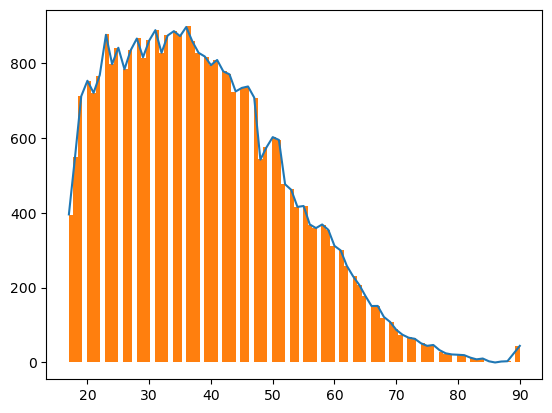

In [20]:
def age_hist(epsilon):
    hist = adult['Age'].value_counts()
    noisy_hist = hist.apply(lambda x: laplace_mech(x, sensitivity=1, epsilon=epsilon))
    return noisy_hist

plt.plot(age_hist(1.0).sort_index());
plt.hist(adult['Age'], bins=100);
age_hist(1.0)

## Question 2

Using the *synthetic representation* of the differentially private histogram from question 1, answer the range query, "how many people are between the ages of 30 and 42?"

In [21]:
def range_query_synth(syn_rep, a, b):
    total = 0
    for i in range(a, b):
        total += syn_rep[i]
    return total

def between_30_42_syn(epsilon):
    syn_rep = age_hist(1.0)
    return range_query_synth(syn_rep, 30, 42)
    
print('Synthetic answer:', between_30_42_syn(1.0))
# i can answer infinity quiries using syn_rep without using aditional privacy budget
# advantage:
# -  use whole privacy busget at once to greate a synthetic representation
# - answer as many queries as you want for 0 privacy cost, via post processing
print('True answer:', len(adult[(adult['Age'] >= 30) & (adult['Age'] < 42)]))

Synthetic answer: 10215.636382680277
True answer: 10215


accuracy 
    - for samkk ranges, similar ti tegular laplace mechanism because we sum few noise samples
    - for large ranges, worse than laplace mechanism, beacus we summany noise samples

## Question 3

Using the synthetic representation generated by the `age_hist` function, derive a differentially private approximation of the *one-way marginal* for the `Age` column of the `adult` dataset.

approach:
1) generate hist (synthetic rep)
2) ocnvert hist to one way marginal distribution
3) sample from the one way marginal to get synthetic data

one way marginal distribution for the "age" column is:
a probability distribution over (just) the ages

In [22]:
def age_marginal(epsilon):
    # 1) generate hist
    hist = age_hist(epsilon)
    # 2) convert hist to marginal distribution 
    # probability distribution: if i pick random person from the population
    # what is the probability that they will be C years old?
    # a histogram also tells me the answer to the question
    marginal = hist.clip(lower=0) / hist.clip(lower=0).sum()
    # 3) sample from the one way marginal to get synthetic data
    return marginal.to_frame(name='probability').reset_index()


marginal = age_marginal(1.0)
print('Sum of marginal probabilities:', np.sum(marginal['probability']))
marginal

Sum of marginal probabilities: 1.0


,Age,probability
0,36,0.027586
1,31,0.027372
2,34,0.027191
3,23,0.026955
4,35,0.026909
...,...,...
68,83,0.000207
69,88,0.000085
70,85,0.000194
71,86,0.000000


## Question 4

Using the marginal constructed by `age_marginal`, sample *synthetic ages* from the probability distribution it represents.

In [23]:
def gen_samples(n, marginal):
    return marginal.sample(n=n, replace=True, weights='probability')

marginal = age_marginal(1.0)
syn_data = pd.DataFrame(gen_samples(5, marginal), columns=['Age'])
syn_data

,Age
1,31
9,25
10,27
39,56
18,26


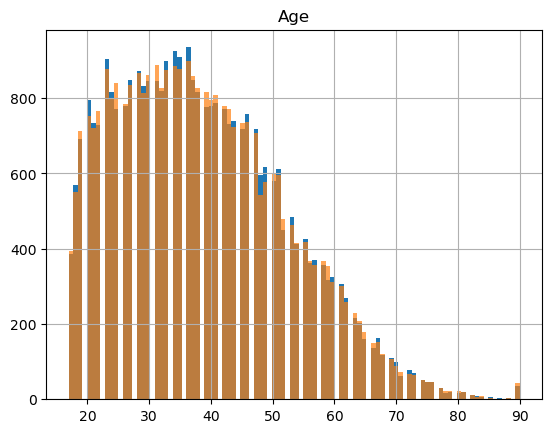

In [24]:
syn_data = pd.DataFrame(gen_samples(len(adult), marginal), columns=['Age'])
syn_data.hist(bins=100)
adult['Age'].hist(alpha=0.7, bins = 100);

## Accuracy of Synthetic Representation

In [25]:
epsilon = 1.0
syn_rep = age_hist(epsilon)

# Query 1: count with 40 <= age < 43
true_answer = len(adult[(adult['Age'] >= 40) & (adult['Age'] < 43)])
print('Q1 percent error, synthetic representation:', 
      pct_error(true_answer, range_query_synth(syn_rep, 40, 43)))

lap_answer = laplace_mech(true_answer, 1, epsilon)
print('Q1 percent error, Laplace mechanism:', 
      pct_error(true_answer, lap_answer))

Q1 percent error, synthetic representation: 0.004941885628534552
Q1 percent error, Laplace mechanism: 0.005040163496198345


In [26]:
# Query 2: count with 25 <= age < 53
true_answer = len(adult[(adult['Age'] >= 25) & (adult['Age'] < 53)])
print('Q2 percent error, synthetic representation:', 
      pct_error(true_answer, range_query_synth(syn_rep, 25, 53)))

lap_answer = laplace_mech(true_answer, 1, epsilon)
print('Q2 percent error, Laplace mechanism:', 
      pct_error(true_answer, lap_answer))

Q2 percent error, synthetic representation: 0.011142485851138518
Q2 percent error, Laplace mechanism: 0.015784470947581487


## Question 5

Which approach gives more accurate answers: the Laplace mechanism or the synthetic representation? Under what conditions is the synthetic representation good, and under what conditions is it not as good?

- for the small intervals the synthetic representation is roughly as good as the Laplace mechanism
- for big intervals the synthetic representation is much worse then laplace mechanism , because we add togather many noise samples to get a single answer
- there are some questions you cant answer: picking a particular synthetic representation limits the things you can ask questions about
- why not just make a synthetic representation of everything? the curse of dimensionality means you cant

## Question 6

Implement a synthetic representation for *two dimensions*: `Age` and `Occupation`.

In [27]:
def age_occupation_hist(epsilon):
    hist = adult[['Age', 'Occupation']].value_counts()
    dp_hist = hist.apply(lambda x: laplace_mech(x, sensitivity=1, epsilon=epsilon))
    return dp_hist.clip(lower=0)

age_occupation_hist(1.0)

Age  Occupation       
19   Other-service        166.730546
37   Craft-repair         153.741644
18   Other-service        151.212312
38   Exec-managerial      149.224597
     Craft-repair         148.875345
                             ...    
72   Craft-repair           0.089346
71   Tech-support           0.899790
     Machine-op-inspct      1.432137
     Handlers-cleaners      0.000000
90   Transport-moving       0.857892
Name: count, Length: 843, dtype: float64

Bad way
- 1 way marginal for age -> syn Ages
                                            > concatenate
- 1 way marginal for occupation -> syn Occ

^

| does not preserve correlations in the dataset


matches format but does not preserve statistical properties, does not preserve correlations 





## Question 7

Using the synthetic representation from Question 6, implement functions to calculate the *two-way marginal distribution* and generate synthetic data samples.

More than 3 way marginal is not needed

In [ ]:
def age_occupation_marginal(epsilon):
    # 1 generate synthetic representation
    syn_rep = age_occupation_hist(epsilon)
    # 2 normalize to get probability distribution
    marginal = syn_rep / syn_rep.sum()
    return marginal.to_frame(name='probability').reset_index()

def gen_samples(n, marginal):
    samples = marginal.sample(n=n, replace=True, weights='probability')
    return samples.drop(columns='probability')

marginal = age_occupation_marginal(1.0)
gen_samples(15, marginal)


,Age,Occupation
87,42,Craft-repair
180,23,Exec-managerial
390,43,Tech-support
382,64,Craft-repair
113,25,Other-service
68,32,Prof-specialty
388,34,Farming-fishing
7,21,Other-service
3,38,Exec-managerial
378,64,Prof-specialty


## Question 8

Generate synthetic data for the Age and Occupation columns by using a two-way marginal as a *conditional distribution*. Use `age_marginal` to generate data for the Age column, then use `age_occupation_marginal` to generate the Occupation column by *conditioning* on the Age column.

In [143]:
def gen_age_occupation_conditional(n, epsilon):
    def gen_conditional(s,m,cond,target):
        #limit m tot he roes where cond == s
        limited = m[m[cond] == s]
        return limited.sample(n=1,weights='probability')[target].iloc[0]
    
    # 1 generate 1 way marginal for age
    m1 = age_marginal(epsilon/2)
    # 2 generate 2 way marginal for age and occupation to treat as a 
    #   conditional probability for occupation given age
    m2  = age_occupation_marginal(epsilon/2)
    # 3 sample ages using(1)
    samples = gen_samples(n, m1)
    # 4 sample occupation given ages using(2)
    samples['Occupation'] = [gen_conditional(s,m2,'Age', 'Occupation') for s in samples['Age']]
    return samples

gen_age_occupation_conditional(15, 1.0)

,Age,Occupation
51,68,Other-service
21,22,Sales
43,60,Farming-fishing
5,33,Transport-moving
28,47,Prof-specialty
22,20,Other-service
2,34,Protective-serv
15,41,Farming-fishing
11,32,Exec-managerial
20,43,Transport-moving


using the graphical model we can make a chain of the 2 way marginals fromm one to tanohte 